In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import ElasticNet

# Считываем данные

In [2]:
train = pd.read_csv('train.csv', header=None).to_numpy()
test = pd.read_csv('test.csv', header=None).to_numpy()
etalon_train = pd.read_csv('etalon_for_train.csv', header=None).to_numpy()
etalon_test = pd.read_csv('etalon_for_test.csv', header=None).to_numpy()

print(f"Обучающая выборка: {train.shape}")
print(f"Тестовая выборка: {test.shape}")
print(f"Эталон обучающий: {etalon_train.shape}")
print(f"Эталон тестовый: {etalon_test.shape}")

Обучающая выборка: (1000, 5000)
Тестовая выборка: (500, 5000)
Эталон обучающий: (1000, 5000)
Эталон тестовый: (500, 5000)


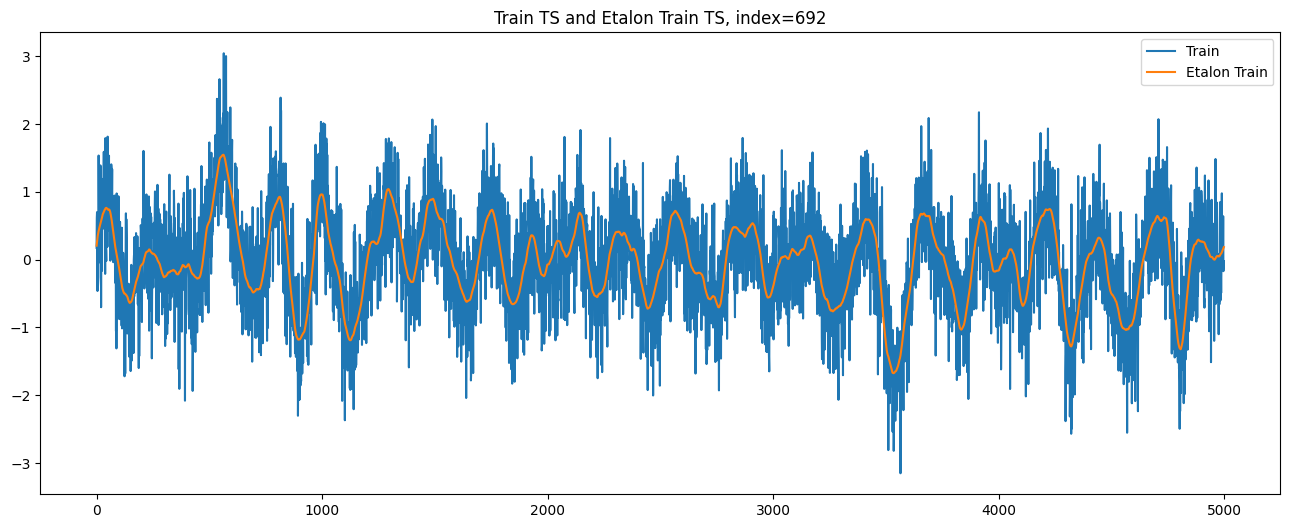

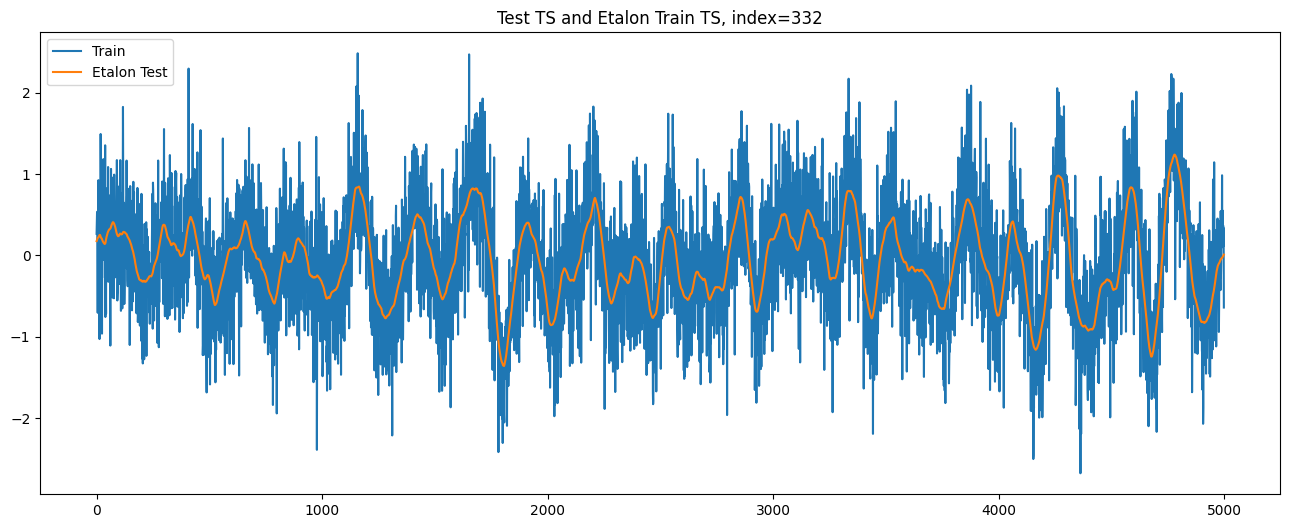

In [3]:
rand_idx = np.random.randint(0, train.shape[0])

plt.figure(figsize=(16, 6))
plt.plot(train[rand_idx], label='Train')
plt.plot(etalon_train[rand_idx], label='Etalon Train')
plt.title(f"Train TS and Etalon Train TS, index={rand_idx}")
plt.legend()
plt.show()

rand_idx = np.random.randint(0, test.shape[0])
plt.figure(figsize=(16, 6))
plt.plot(test[rand_idx], label='Train')
plt.plot(etalon_test[rand_idx], label='Etalon Test')
plt.title(f"Test TS and Etalon Train TS, index={rand_idx}")
plt.legend()
plt.show()

In [4]:
train_size = 4000

X_train = train[:, :train_size]
y_train = train[:, train_size:]

X_test = test[:, :train_size]
y_test = test[:, train_size:]

y_etalon_test = etalon_test[:, train_size:]

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

X_train: (1000, 4000)
y_train: (1000, 1000)
X_test: (500, 4000)
y_test: (500, 1000)


# Обучаем модель - ElasticNet (Линейная регрессия с L1 и L2 регуляризациями)

In [5]:
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.2)
elastic_net.fit(X_train, y_train)

,alpha,0.1
,l1_ratio,0.2
,fit_intercept,True
,precompute,False
,max_iter,1000
,copy_X,True
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [6]:
test_preds = elastic_net.predict(X_test)
test_preds.shape

(500, 1000)

# Вычисляем метрики и строим графики

In [20]:
mean_error = np.mean(test_preds - y_etalon_test, axis=0)
rms = np.sqrt(np.mean((test_preds - y_etalon_test - mean_error)**2, axis=0))

print(f"Средняя ошибка (ME): {round(mean_error.mean(), 5)}")
print(f"Среднеквадратичная погрешность (СКП): {round(rms.mean(), 5)}")

Средняя ошибка (ME): 0.00684
Среднеквадратичная погрешность (СКП): 0.53739


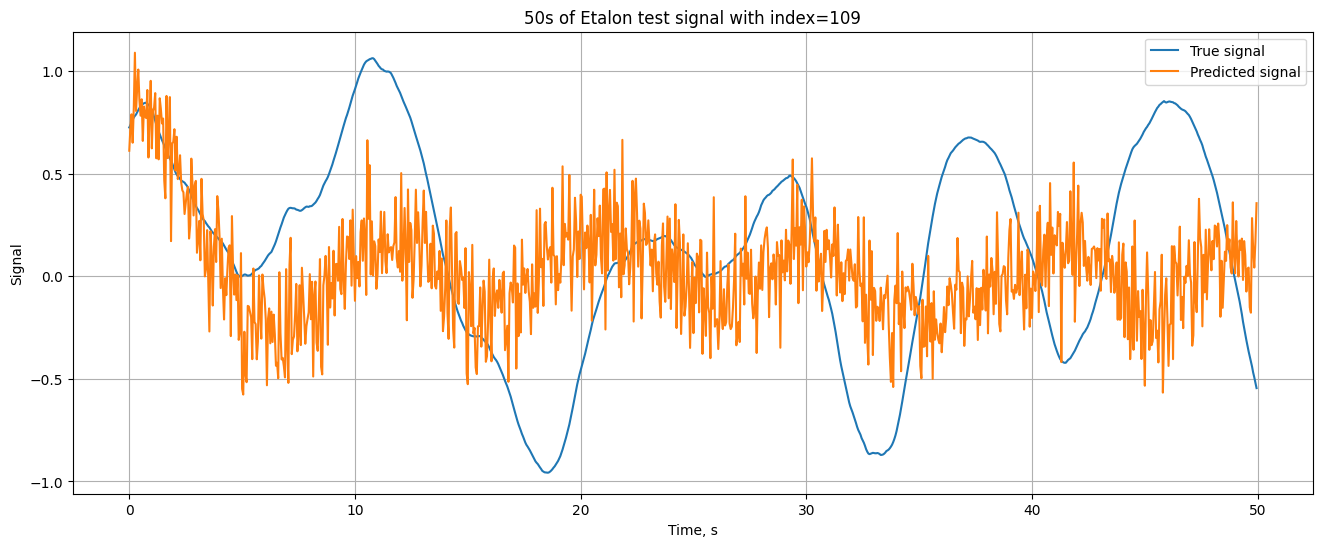

In [21]:
rand_idx = np.random.randint(0, test_preds.shape[0])

dt = 0.05

plt.figure(figsize=(16, 6))
plt.plot((np.arange(test_preds.shape[1]) * dt), y_etalon_test[rand_idx], label='True signal')
plt.plot((np.arange(test_preds.shape[1]) * dt), test_preds[rand_idx], label='Predicted signal')
plt.xlabel('Time, s')
plt.ylabel('Signal')
plt.title(f'50s of Etalon test signal with index={rand_idx}')
plt.legend()
plt.grid(True)
plt.show()

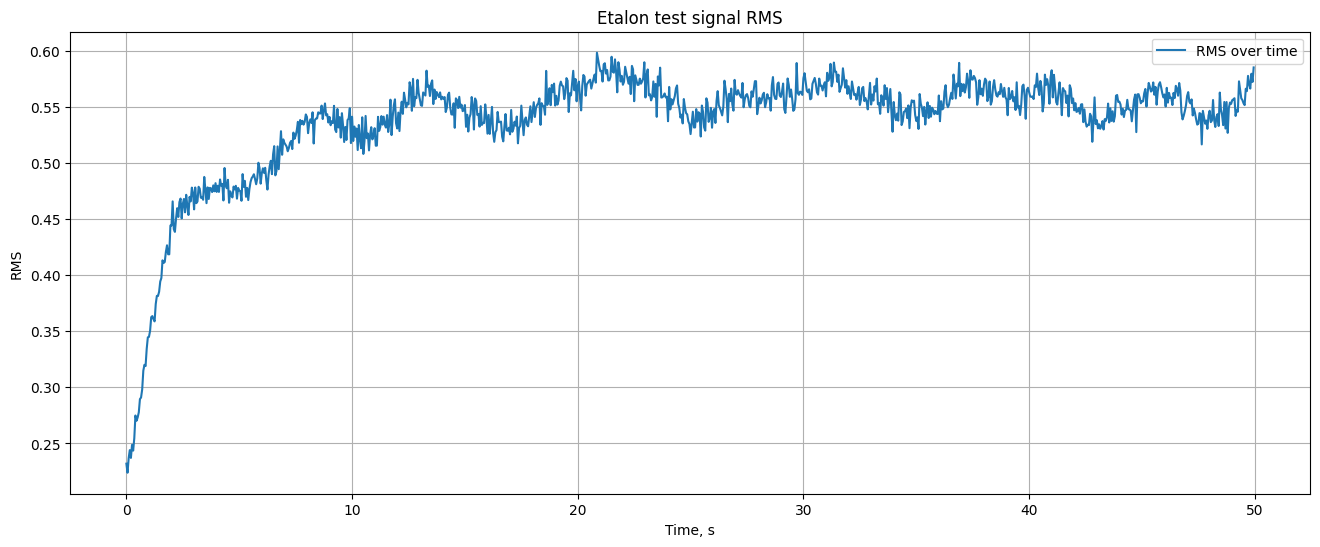

In [23]:
plt.figure(figsize=(16, 6))
plt.plot(np.arange(test_preds.shape[1]) * dt, rms, label='RMS over time')
plt.xlabel('Time, s')
plt.ylabel('RMS')
plt.title('Etalon test signal RMS')
plt.grid(True)
plt.legend()
plt.show()